In [9]:
import os
import yaml
import pprint
import glob
import torch
import cv2
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import pyrealsense2 as rs
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import numpy as np
import copy
from scipy.spatial.transform import Rotation as R

import INUVisionLib as ivl
import INUVisionCall as ivc

print("\n라이브러리 로드")


라이브러리 로드


# **호출 구조 지정**

노드 실행

와이드 서치 - 테이블 업로드

데이터 콜링 - 

ID - 6D 반환

(로봇팔 이동후) 파인 - ID - 



[INFO] 카메라 데이터 캡처 중...
[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


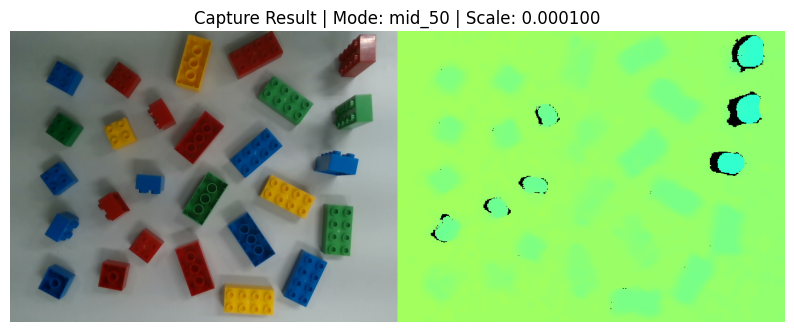

✅ 카메라 스트리밍 안전 종료 완료.
[INFO] 전체 객체 탐색(Search Wide) 실행 중...
🎯 [SUCCESS] 29개의 타겟 객체 마스크 병합 완료
✂️ [INFO] 억제됨: '2x2_green' (면적:2327)가 '4x2_green' (면적:2358)에 99.8% 포함됨.
✂️ [INFO] 억제됨: '4x2_red' (면적:1749)가 '2x2_red' (면적:1749)에 99.9% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 27개
 - 🏷️ 4x2_green (신뢰도: 0.96)
 - 🏷️ 4x2_blue (신뢰도: 0.94)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.95)
 - 🏷️ 4x2_red (신뢰도: 0.94)
 - 🏷️ 4x2_yellow (신뢰도: 0.89)
 - 🏷️ 4x2_red (신뢰도: 0.96)
 - 🏷️ 4x2_blue (신뢰도: 0.93)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 4x2_red (신뢰도: 0.93)
 - 🏷️ 4x2_green (신뢰도: 0.95)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.91)
 - 🏷️ 4x2_red (신뢰도: 0.92)
 - 🏷️ 4x2_blue (신뢰도: 0.89)
 - 🏷️ 2x2_blue (신뢰도: 0.91)
 - 🏷️ 2x2_blue (신뢰도: 0.92)
 - 🏷️ 2x2_red (신뢰도: 0.69)
 - 🏷️ 4x2_green (신뢰도: 0.32)
 - 🏷️ 2x2_blue (신뢰도: 0.91)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 2x2_red (신뢰도: 0.81)
 - 🏷️ 2x2_yellow (신뢰도: 0.89)
 - 🏷️ 2x2_red (신뢰도: 0.94)
 - 🏷️ 2x2_red (신뢰도: 0.84)
 - 🏷️ 2x2_red (신뢰도: 0.35)
 - 🏷️ 2x2_blue (신뢰도: 0.84)

[INFO] 3D

In [ ]:
# 1. 매니저 객체 생성
vision = ivc.VisionManager()

# 2. 카메라 캡처 (리턴값 받을 필요 없이 알아서 내부에 저장됨)
vision.capture_camera(visualize=True)

# 3. 서치 실행
vision.run_search(visualize=False)

# 4. 원하는 타겟 ID로 포즈 추출 (예: 7번 = 4x2_blue, 두 번째 객체 = local_id 1)
my_target_pose = vision.get_pose_by_id(target_id=7, local_id=0)

if my_target_pose is not None:
    x, y, z = my_target_pose["x_mm"], my_target_pose["y_mm"], my_target_pose["z_mm"]
    roll, pitch, yaw = my_target_pose["roll_deg"], my_target_pose["pitch_deg"], my_target_pose["yaw_deg"]

    print("--- 6D Pose Result ---")
    print(f"class: {my_target_pose['class_name']}")
    print(f"local_id: {my_target_pose['local_id']}")
    print(f"global_idx: {my_target_pose.get('global_idx', 'N/A')}")
    print(f"XYZ mm: {x:.1f}, {y:.1f}, {z:.1f}")
    print(f"RPY deg: {roll:.2f}, {pitch:.2f}, {yaw:.2f}")
    print("----------------------")

# # 다른 ID도 연속해서 바로바로 찾을 수 있습니다.
# battery_pose = vision.get_pose_by_id(target_id=34)